# Week 4 — Class-Balanced Loss Experiments
---

### Motivation
Week 3 showed that on DermaMNIST (IR=58.7), **all** TL strategies struggle with minority classes despite strong AUC. The Acc–F1 gap (0.22) reveals the standard cross-entropy loss is distorted by the dominant class (melanocytic nevi = 67% of test set).

| Component | What we do | 
|---|---|
| **1. Strategy Selection** | Show optimal TL strategy depends on dataset IR | 
| **2. Loss Function Study** | Compare Standard CE, ENS Weighted CE (β=0.99), Focal Loss (γ=2) | 
| **3. Calibration Analysis** | Per-class ECE across all methods | 

### Experimental Protocol
| Config | Value |
|--------|-------|
| Random seed | 42 |
| Train/Val/Test split | MedMNIST official splits |
| Optimizer | AdamW |
| Epochs | 30 |
| Image size | 224×224 (ResNet standard) |
| Batch size | 64 |
| **Only variable changed** | Loss function (3 variants : Standard CE / ENS Weighted CE / Focal Loss) |
| Frameworks | PyTorch, torchvision, medmnist |

## Setup & Imports

In [1]:
!pip install medmnist torchvision scikit-learn matplotlib seaborn tqdm Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.1 MB/s eta 0:00:00


In [2]:
import os
import random
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

import medmnist
from medmnist import DermaMNIST, BloodMNIST, INFO

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize

from tqdm.notebook import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Output directories ───────────────────────────────────────────────────────
os.makedirs('../figures',     exist_ok=True)
os.makedirs('../experiments', exist_ok=True)
os.makedirs('../models',      exist_ok=True)

print(f"medmnist version: {medmnist.__version__}")
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Using device: cuda
GPU: Tesla T4
medmnist version: 3.0.2
torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


## 1. Hyperparameters & Global Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# All hyperparameters are identical to Week 3 for fair comparison.
# The only variable that changes across experiments is the loss function.
# ─────────────────────────────────────────────────────────────────────────────

CONFIG = {
    # Data
    'image_size'  : 224,          # ResNet-50 standard input
    'batch_size'  : 64,
    'num_workers' : 2,

    # Training
    'num_epochs'  : 30,
    'seed'        : 42,

    # Differential LR (backbone vs head)
    'lr_backbone' : 1e-5,
    'lr_head'     : 1e-3,
    'lr_linear_probe': 1e-3,

    # Regularization
    'weight_decay': 1e-4,
    'dropout'     : 0.3,

    # Scheduler
    'scheduler'   : 'cosine',

    # Early stopping
    'patience'    : 7,

    # Class-balanced loss
    'beta_ens'    : 0.99,
}

# Datasets
DATASETS = ['dermamnist', 'bloodmnist']

# Imbalance Ratios computed during Week 2 EDA
IMBALANCE_RATIOS = {
    'dermamnist': 58.7,   # severe   — IR ≥ 20 → full FT + class-balanced loss
    'bloodmnist':  2.7,   # balanced — IR <  5 → control experiment
}

print("Global configuration:")
for k, v in CONFIG.items():
    print(f"  {k:30s}: {v}")

print("\nImbalance Ratios and strategy mapping:")
for ds, ir in IMBALANCE_RATIOS.items():
    if ir >= 20:
        strategy = "Full FT + class-balanced loss  (IR ≥ 20)"
    elif ir >= 5:
        strategy = "Full FT + standard CE          (5 ≤ IR < 20)"
    else:
        strategy = "Partial FT suffices            (IR < 5)"
    print(f"  {ds:15s}: IR={ir:5.1f}  →  {strategy}")

Global configuration:
  image_size                    : 224
  batch_size                    : 64
  num_workers                   : 2
  num_epochs                    : 30
  seed                          : 42
  lr_backbone                   : 1e-05
  lr_head                       : 0.001
  lr_linear_probe               : 0.001
  weight_decay                  : 0.0001
  dropout                       : 0.3
  scheduler                     : cosine
  patience                      : 7
  beta_ens                      : 0.99

Imbalance Ratios and strategy mapping:
  dermamnist     : IR= 58.7  →  Full FT + class-balanced loss  (IR ≥ 20)
  bloodmnist     : IR=  2.7  →  Partial FT suffices            (IR < 5)


## 2. Data Loading & Transforms

In [4]:
# ── MedMNIST dataset info ─────────────────────────────────────────────────────
for ds_name in DATASETS:
    info = INFO[ds_name]
    print(f"\n{'='*55}")
    print(f"Dataset : {ds_name.upper()}")
    print(f"  Task         : {info['task']}")
    print(f"  # Classes    : {info['n_channels']} channels, {len(info['label'])} classes")
    print(f"  Labels       : {info['label']}")
    print(f"  License      : {info['license']}")


Dataset : DERMAMNIST
  Task         : multi-class
  # Classes    : 3 channels, 7 classes
  Labels       : {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
  License      : CC BY-NC 4.0

Dataset : BLOODMNIST
  Task         : multi-class
  # Classes    : 3 channels, 8 classes
  Labels       : {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
  License      : CC BY 4.0


In [5]:
# ── Transforms (identical to Week 3) ─────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:", train_transform)
print("\nVal/Test transform:", val_transform)

Train transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [6]:
def compute_class_weights(dataset, beta):
    """
    Effective Number of Samples weighting (Cui et al., CVPR 2019).
    w_c = (1 - beta) / (1 - beta^n_c), normalised so weights sum to n_classes.
    beta=0.99 gives a softer correction than pure inverse-frequency (beta→1),
    which was tested and produced an extreme weight ratio (58.7x) on DermaMNIST.
    """
    labels    = np.array([dataset[i][1].item() for i in range(len(dataset))])
    n_classes = len(np.unique(labels))
    counts    = np.bincount(labels, minlength=n_classes).astype(float)
    eff_num   = 1.0 - np.power(beta, counts)
    weights   = (1.0 - beta) / eff_num
    weights   = weights / weights.sum() * n_classes   # normalise
    return torch.tensor(weights, dtype=torch.float32), counts

In [7]:
def get_dataloaders(dataset_name, batch_size, num_workers=2):
    """Load MedMNIST dataset and return train/val/test DataLoaders + raw train_ds."""
    dataset_map  = {'dermamnist': DermaMNIST, 'bloodmnist': BloodMNIST}
    DatasetClass = dataset_map[dataset_name]
    info         = INFO[dataset_name]
    n_classes    = len(info['label'])

    train_ds = DatasetClass(split='train', transform=train_transform,
                            download=True, as_rgb=True)
    val_ds   = DatasetClass(split='val',   transform=val_transform,
                            download=True, as_rgb=True)
    test_ds  = DatasetClass(split='test',  transform=val_transform,
                            download=True, as_rgb=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"[{dataset_name}] Train: {len(train_ds):>5} | "
          f"Val: {len(val_ds):>5} | Test: {len(test_ds):>5} | "
          f"Classes: {n_classes}")

    return train_loader, val_loader, test_loader, n_classes, info, train_ds


# ── Load datasets & compute class weights ────────────────────────────────────
dataloaders   = {}
class_weights = {}
class_counts  = {}

for ds_name in DATASETS:
    train_loader, val_loader, test_loader, n_classes, info, train_ds = \
        get_dataloaders(ds_name, CONFIG['batch_size'], CONFIG['num_workers'])
    dataloaders[ds_name] = {
        'train': train_loader, 'val': val_loader, 'test': test_loader,
        'n_classes': n_classes, 'info': info,
    }
    w, counts = compute_class_weights(train_ds, beta=CONFIG['beta_ens'])
    class_weights[ds_name] = w
    class_counts[ds_name]  = counts
    ratio = w.max().item() / w.min().item()
    print(f"  ENS weights (β={CONFIG['beta_ens']}): weight ratio={ratio:.1f}x | {w.numpy().round(3).tolist()}")

100%|██████████| 19.7M/19.7M [00:29<00:00, 674kB/s]


[dermamnist] Train:  7007 | Val:  1003 | Test:  2005 | Classes: 7
  ENS weights (β=0.99): weight ratio=1.8x | [0.9120000004768372, 0.8429999947547913, 0.8199999928474426, 1.4839999675750732, 0.8199999928474426, 0.8199999928474426, 1.3009999990463257]


100%|██████████| 35.5M/35.5M [00:28<00:00, 1.24MB/s]


[bloodmnist] Train: 11959 | Val:  1712 | Test:  3421 | Classes: 8
  ENS weights (β=0.99): weight ratio=1.0x | [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 3. Model Architecture & Loss Functions

We use **Full Fine-Tuning** (the Week 3 main method) with three different loss functions:

| Loss Function | Description | Variable |
|---|---|---|
| **Standard CE** | Baseline — identical to Week 3 | — |
| **ENS Weighted CE** (β=0.99) | Effective Number of Samples weighting | Static per-class weight |
| **Focal Loss** (γ=2) | Down-weights easy examples dynamically | Per-sample dynamic weight |

The model architecture is **identical to Week 3**: ResNet-50 (ImageNet V2) with differential LR.

In [8]:
def build_model(n_classes, mode='full_finetune', dropout=0.3):
    """
    Build ResNet-50 model — identical to Week 3.
    mode: 'full_finetune' (all layers trainable) | 'linear_probe' (head only)
    """
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

    if mode == 'linear_probe':
        for param in model.parameters():
            param.requires_grad = False
    else:  # full_finetune
        for param in model.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features   # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, n_classes)
    )
    return model


class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., CVPR 2017).
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)

    Unlike static weighting, focal loss dynamically down-weights easy examples
    (high p_t) so the model focuses on hard, misclassified samples.
    gamma=2 is the standard value from the original paper.
    """
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

    def __repr__(self):
        return f'FocalLoss(gamma={self.gamma})'


def count_trainable_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# Quick sanity check
for mode in ['linear_probe', 'full_finetune']:
    m = build_model(n_classes=7, mode=mode)
    total, trainable = count_trainable_params(m)
    pct = 100 * trainable / total
    print(f"{mode:20s} | Total: {total:>10,} | Trainable: {trainable:>10,} ({pct:.1f}%)")

# Print class weight analysis
print("\n── Class weight analysis ────────────────────────────────────────────────")
for ds_name in DATASETS:
    w     = class_weights[ds_name].numpy()
    ratio = w.max() / w.min()
    info  = dataloaders[ds_name]['info']
    print(f"\n  {ds_name.upper()} (IR={IMBALANCE_RATIOS[ds_name]}, β=0.99, weight ratio={ratio:.1f}x):")
    for cls_name, weight in zip(info['label'].values(), w):
        print(f"    {cls_name:50s}: {weight:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


linear_probe         | Total: 23,522,375 | Trainable:     14,343 (0.1%)
full_finetune        | Total: 23,522,375 | Trainable: 23,522,375 (100.0%)

── Class weight analysis ────────────────────────────────────────────────

  DERMAMNIST (IR=58.7, β=0.99, weight ratio=1.8x):
    actinic keratoses and intraepithelial carcinoma   : 0.9121
    basal cell carcinoma                              : 0.8427
    benign keratosis-like lesions                     : 0.8202
    dermatofibroma                                    : 1.4840
    melanoma                                          : 0.8202
    melanocytic nevi                                  : 0.8199
    vascular lesions                                  : 1.3008

  BLOODMNIST (IR=2.7, β=0.99, weight ratio=1.0x):
    basophil                                          : 1.0001
    eosinophil                                        : 0.9999
    erythroblast                                      : 1.0000
    immature granulocytes(myelocytes, metamyel

## 4. Training Engine

In [9]:
def get_optimizer(model, config):
    """
    Differential LR 
    backbone ← lr_backbone (1e-5), head ← lr_head (1e-3).
    """
    head_params     = list(model.fc.parameters())
    head_ids        = set(id(p) for p in head_params)
    backbone_params = [p for p in model.parameters()
                       if id(p) not in head_ids and p.requires_grad]
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': config['lr_backbone']},
        {'params': head_params,     'lr': config['lr_head']},
    ], weight_decay=config['weight_decay'])
    return optimizer


def get_scheduler(optimizer, config, n_epochs):
    if config['scheduler'] == 'cosine':
        return CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-7)
    elif config['scheduler'] == 'step':
        return StepLR(optimizer, step_size=config.get('step_size', 10),
                      gamma=config.get('gamma', 0.1))
    return None


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += inputs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """
    Always evaluates with standard CrossEntropyLoss for fair metric comparison,
    regardless of what loss was used during training.
    """
    std_criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(inputs)
        loss    = std_criterion(outputs, labels)
        total_loss += loss.item() * inputs.size(0)
        probs  = torch.softmax(outputs, dim=1)
        preds  = probs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def train_model(model, train_loader, val_loader, criterion, config,
                n_epochs=None, device=DEVICE, exp_name='exp'):
    """
    Full training loop with early stopping and history tracking.
    """
    if n_epochs is None:
        n_epochs = config['num_epochs']

    optimizer = get_optimizer(model, config)
    scheduler = get_scheduler(optimizer, config, n_epochs)
    model     = model.to(device)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [],
        'lr': [],
    }

    best_val_acc     = 0.0
    best_model_wts   = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start_time = time.time()
    print(f"\n{'─'*65}")
    print(f"  Training : {exp_name}")
    print(f"  Loss     : {criterion}")
    print(f"{'─'*65}")
    print(f"{'Epoch':>6} {'TrainLoss':>10} {'TrainAcc':>10} "
          f"{'ValLoss':>10} {'ValAcc':>10} {'LR':>10}")
    print(f"{'─'*65}")

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion,
                                        optimizer, device)
        v_loss, v_acc, _, _, _ = evaluate(model, val_loader, device)
        current_lr = optimizer.param_groups[-1]['lr']

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['lr'].append(current_lr)

        if scheduler:
            scheduler.step()

        if v_acc > best_val_acc:
            best_val_acc     = v_acc
            best_model_wts   = copy.deepcopy(model.state_dict())
            patience_counter = 0
            marker = ' ★'
        else:
            patience_counter += 1
            marker = ''

        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"{epoch:>6} {t_loss:>10.4f} {t_acc:>10.4f} "
                  f"{v_loss:>10.4f} {v_acc:>10.4f} {current_lr:>10.2e}{marker}")

        if patience_counter >= config['patience']:
            print(f"  → Early stopping at epoch {epoch} (patience={config['patience']})")
            break

    elapsed = time.time() - start_time
    print(f"{'─'*65}")
    print(f"  Best Val Acc: {best_val_acc:.4f} | Training time: {elapsed:.1f}s")

    model.load_state_dict(best_model_wts)
    torch.save(best_model_wts, f'../models/{exp_name}_best.pth')
    return model, history

print("Training engine defined.")

Training engine defined.


## 5. Experiments — 3 Loss Functions × 2 Datasets

| # | Dataset | Loss Function | Role |
|---|---|---|---|
| 1 | DermaMNIST | Standard CE | W3 reference (re-run) |
| 2 | DermaMNIST | ENS Weighted CE (β=0.99) | Class-balanced ablation |
| 3 | DermaMNIST | Focal Loss (γ=2) | Dynamic weighting ablation |
| 4 | BloodMNIST | Standard CE | W3 reference (re-run) |
| 5 | BloodMNIST | ENS Weighted CE (β=0.99) | Control — should barely change |
| 6 | BloodMNIST | Focal Loss (γ=2) | Control — should barely change |

In [10]:
EXPERIMENTS = [
    {'dataset': 'dermamnist', 'loss': 'standard',     'label': 'Standard CE'},
    {'dataset': 'dermamnist', 'loss': 'ens_weighted',  'label': 'ENS Weighted CE (β=0.99)'},
    {'dataset': 'dermamnist', 'loss': 'focal',         'label': 'Focal Loss (γ=2)'},
    {'dataset': 'bloodmnist', 'loss': 'standard',     'label': 'Standard CE'},
    {'dataset': 'bloodmnist', 'loss': 'ens_weighted',  'label': 'ENS Weighted CE (β=0.99)'},
    {'dataset': 'bloodmnist', 'loss': 'focal',         'label': 'Focal Loss (γ=2)'},
]

all_results   = {}
all_histories = {}
all_models    = {}

for exp in EXPERIMENTS:
    ds_name   = exp['dataset']
    loss_type = exp['loss']
    exp_key   = f"{ds_name}__{loss_type}"

    train_loader = dataloaders[ds_name]['train']
    val_loader   = dataloaders[ds_name]['val']
    test_loader  = dataloaders[ds_name]['test']
    n_classes    = dataloaders[ds_name]['n_classes']
    info         = dataloaders[ds_name]['info']

    # ── Build criterion ───────────────────────────────────────────────────────
    if loss_type == 'standard':
        criterion = nn.CrossEntropyLoss()
    elif loss_type == 'ens_weighted':
        w = class_weights[ds_name].to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=w)
    elif loss_type == 'focal':
        criterion = FocalLoss(gamma=2.0)

    # ── Reset seed for fair comparison ────────────────────────────────────────
    torch.manual_seed(SEED)
    model = build_model(n_classes=n_classes, mode='full_finetune',
                        dropout=CONFIG['dropout'])

    trained_model, history = train_model(
        model, train_loader, val_loader,
        criterion=criterion,
        config=CONFIG,
        n_epochs=CONFIG['num_epochs'],
        device=DEVICE,
        exp_name=exp_key
    )

    # ── Test evaluation — always with standard CE for fair metrics ────────────
    _, test_acc, preds, labels, probs = evaluate(trained_model, test_loader, DEVICE)

    labels_bin = label_binarize(labels, classes=list(range(n_classes)))
    try:
        auc_score = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_score = float('nan')
    f1 = f1_score(labels, preds, average='macro', zero_division=0)

    all_results[exp_key] = {
        'test_acc': test_acc, 'auc': auc_score, 'f1_macro': f1,
        'preds': preds, 'labels': labels, 'probs': probs,
        'n_classes': n_classes, 'class_names': list(info['label'].values()),
        'dataset': ds_name, 'loss_type': loss_type, 'label': exp['label'],
    }
    all_histories[exp_key] = history
    all_models[exp_key]    = trained_model

    print(f"\n[TEST] {exp_key:40s}  Acc={test_acc:.4f}  AUC={auc_score:.4f}  F1={f1:.4f}")


─────────────────────────────────────────────────────────────────
  Training : dermamnist__standard
  Loss     : CrossEntropyLoss()
─────────────────────────────────────────────────────────────────
 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc         LR
─────────────────────────────────────────────────────────────────
     1     0.9853     0.6713     0.8378     0.7159   1.00e-03 ★
     2     0.8030     0.7077     0.7670     0.7218   9.97e-04 ★
     3     0.7506     0.7217     0.7327     0.7448   9.89e-04 ★
     5     0.6910     0.7421     0.6917     0.7388   9.57e-04
     6     0.6769     0.7477     0.6846     0.7537   9.33e-04 ★
     8     0.6466     0.7574     0.6472     0.7667   8.72e-04 ★
    10     0.6193     0.7674     0.6536     0.7587   7.94e-04
    15     0.5711     0.7805     0.6216     0.7717   5.52e-04 ★
    20     0.5427     0.7921     0.6341     0.7687   2.97e-04
  → Early stopping at epoch 22 (patience=7)
───────────────────────────────────────────────────────────

## 6. Ablation — Linear Probing + ENS Weighted CE

If backbone adaptation and loss reweighting are both needed for IR ≥ 20, then applying class weights alone — without backbone adaptation — should be insufficient. We test LP + Weighted CE to verify this.

In [11]:
# ── LP + Weighted CE on DermaMNIST — tests loss reweighting without backbone adaptation ──
torch.manual_seed(SEED)
lp_model = build_model(n_classes=dataloaders['dermamnist']['n_classes'],
                        mode='linear_probe', dropout=CONFIG['dropout'])

lp_criterion = nn.CrossEntropyLoss(weight=class_weights['dermamnist'].to(DEVICE))

lp_trained, lp_history = train_model(
    lp_model,
    dataloaders['dermamnist']['train'],
    dataloaders['dermamnist']['val'],
    criterion=lp_criterion,
    config=CONFIG,
    device=DEVICE,
    exp_name='dermamnist__lp_weighted'
)

_, lp_acc, lp_preds, lp_labels, lp_probs = evaluate(
    lp_trained, dataloaders['dermamnist']['test'], DEVICE)

lp_f1 = f1_score(lp_labels, lp_preds, average='macro', zero_division=0)
lp_auc = roc_auc_score(
    label_binarize(lp_labels, classes=list(range(dataloaders['dermamnist']['n_classes']))),
    lp_probs, multi_class='ovr', average='macro'
)

all_results['dermamnist__lp_weighted'] = {
    'test_acc': lp_acc, 'auc': lp_auc, 'f1_macro': lp_f1,
    'preds': lp_preds, 'labels': lp_labels, 'probs': lp_probs,
    'n_classes': dataloaders['dermamnist']['n_classes'],
    'class_names': list(dataloaders['dermamnist']['info']['label'].values()),
    'dataset': 'dermamnist', 'loss_type': 'lp_weighted',
    'label': 'LP + Weighted CE',
}
all_histories['dermamnist__lp_weighted'] = lp_history

print(f"\n[TEST] dermamnist__lp_weighted              Acc={lp_acc:.4f}  AUC={lp_auc:.4f}  F1={lp_f1:.4f}")


─────────────────────────────────────────────────────────────────
  Training : dermamnist__lp_weighted
  Loss     : CrossEntropyLoss()
─────────────────────────────────────────────────────────────────
 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc         LR
─────────────────────────────────────────────────────────────────
     1     1.0849     0.6688     0.8930     0.7069   1.00e-03 ★
     2     0.9292     0.6932     0.8456     0.7208   9.97e-04 ★
     3     0.8807     0.7050     0.8177     0.7228   9.89e-04 ★
     4     0.8525     0.7080     0.8014     0.7238   9.76e-04 ★
     5     0.8298     0.7089     0.7786     0.7298   9.57e-04 ★
     6     0.8232     0.7163     0.7759     0.7388   9.33e-04 ★
     7     0.8084     0.7204     0.7748     0.7438   9.05e-04 ★
     8     0.8075     0.7174     0.7569     0.7547   8.72e-04 ★
    10     0.7907     0.7253     0.7615     0.7428   7.94e-04
    15     0.7686     0.7303     0.7384     0.7507   5.52e-04
  → Early stopping at epoch 15 (pa

## 7. Results Summary Table

In [12]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
ref_f1 = {ds: all_results[f'{ds}__standard']['f1_macro'] for ds in DATASETS}

rows = []
for key, r in all_results.items():
    rows.append({
        'Experiment'    : key,
        'Dataset'       : r['dataset'].upper(),
        'Loss Function' : r['label'],
        'Accuracy'      : round(r['test_acc'], 4),
        'Macro AUC-ROC' : round(r['auc'],      4),
        'Macro F1'      : round(r['f1_macro'],  4),
        'ΔF1 vs Std CE' : round(r['f1_macro'] - ref_f1[r['dataset']], 4),
    })

df_results = pd.DataFrame(rows)
print("\n" + "="*78)
print("RESULTS SUMMARY — Week 4 (Imbalance-Aware Fine-Tuning)")
print("="*78)
print(df_results.to_string(index=False))

df_results.to_csv('../experiments/W4_results_summary.csv', index=False)
print("\nSaved: ../experiments/W4_results_summary.csv")


RESULTS SUMMARY — Week 4 (Imbalance-Aware Fine-Tuning)
              Experiment    Dataset            Loss Function  Accuracy  Macro AUC-ROC  Macro F1  ΔF1 vs Std CE
    dermamnist__standard DERMAMNIST              Standard CE    0.7676         0.9268    0.5474         0.0000
dermamnist__ens_weighted DERMAMNIST ENS Weighted CE (β=0.99)    0.7631         0.9285    0.5386        -0.0088
       dermamnist__focal DERMAMNIST         Focal Loss (γ=2)    0.7511         0.9227    0.5246        -0.0228
    bloodmnist__standard BLOODMNIST              Standard CE    0.9605         0.9980    0.9569         0.0000
bloodmnist__ens_weighted BLOODMNIST ENS Weighted CE (β=0.99)    0.9611         0.9980    0.9578         0.0010
       bloodmnist__focal BLOODMNIST         Focal Loss (γ=2)    0.9439         0.9970    0.9371        -0.0198
 dermamnist__lp_weighted DERMAMNIST         LP + Weighted CE    0.7297         0.8938    0.4107        -0.1367

Saved: ../experiments/W4_results_summary.csv


## 8. Calibration Analysis — Expected Calibration Error (ECE)

A model is well-calibrated when its predicted confidence matches its actual accuracy — that is, when a prediction made with 80% confidence is correct approximately 80% of the time. ECE quantifies the deviation from this ideal.

$$\text{ECE} = \sum_{b=1}^{B} \frac{|\mathcal{B}_b|}{n} \left| \text{acc}(\mathcal{B}_b) - \text{conf}(\mathcal{B}_b) \right|$$

**Key question:** Even if class-balanced losses do not improve F1, do they improve calibration on minority classes?

Calibration is particularly important in clinical settings, where predicted probabilities inform diagnostic decisions — a model that reports 90% confidence but is correct only 60% of the time can mislead clinical judgment. Even if class-balanced losses do not improve macro F1, they may still affect calibration differently across classes. We therefore report ECE alongside standard classification metrics to assess whether loss modifications improve or degrade the reliability of the model's probability estimates.

In [13]:
def compute_ece(probs, labels, n_bins=15):
    """
    Global Expected Calibration Error.
    Bins predictions by confidence and measures acc-conf gap per bin.
    """
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies  = (predictions == labels).astype(float)
    bins        = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if mask.sum() > 0:
            avg_conf = confidences[mask].mean()
            avg_acc  = accuracies[mask].mean()
            ece     += (mask.sum() / len(labels)) * abs(avg_acc - avg_conf)
    return ece


def compute_per_class_ece(probs, labels, n_classes, n_bins=10):
    """
    Per-class ECE: for each class c, treat as a binary problem
    and compute ECE on model confidence for c.
    """
    per_class = {}
    for c in range(n_classes):
        mask = (labels == c)
        if mask.sum() < 5:
            per_class[c] = float('nan')
            continue
        class_conf  = probs[mask, c]
        class_preds = (probs[mask].argmax(axis=1) == c).astype(float)
        bins  = np.linspace(0, 1, n_bins + 1)
        ece_c = 0.0
        for i in range(n_bins):
            m = (class_conf > bins[i]) & (class_conf <= bins[i+1])
            if m.sum() > 0:
                ece_c += (m.sum() / mask.sum()) * abs(class_preds[m].mean() - class_conf[m].mean())
        per_class[c] = ece_c
    return per_class


# ── Compute ECE for all experiments ──────────────────────────────────────────
ece_results = {}
for key, r in all_results.items():
    ece_results[key] = {
        'global'    : compute_ece(r['probs'], r['labels']),
        'per_class' : compute_per_class_ece(r['probs'], r['labels'], r['n_classes']),
    }

# ── ECE summary table ─────────────────────────────────────────────────────────
ece_rows = []
for key, r in all_results.items():
    ece_rows.append({
        'Dataset'       : r['dataset'].upper(),
        'Loss Function' : r['label'],
        'Global ECE'    : round(ece_results[key]['global'], 4),
        'Macro F1'      : round(r['f1_macro'], 4),
        'Macro AUC-ROC' : round(r['auc'],      4),
    })

df_ece = pd.DataFrame(ece_rows)
print("\n" + "="*65)
print("ECE SUMMARY (ECE: lower = better calibration)")
print("="*65)
print(df_ece.to_string(index=False))
df_ece.to_csv('../experiments/W4_ece_summary.csv', index=False)
print("\nSaved: ../experiments/W4_ece_summary.csv")


ECE SUMMARY (ECE: lower = better calibration)
   Dataset            Loss Function  Global ECE  Macro F1  Macro AUC-ROC
DERMAMNIST              Standard CE      0.0199    0.5474         0.9268
DERMAMNIST ENS Weighted CE (β=0.99)      0.0279    0.5386         0.9285
DERMAMNIST         Focal Loss (γ=2)      0.0977    0.5246         0.9227
BLOODMNIST              Standard CE      0.0108    0.9569         0.9980
BLOODMNIST ENS Weighted CE (β=0.99)      0.0073    0.9578         0.9980
BLOODMNIST         Focal Loss (γ=2)      0.0770    0.9371         0.9970
DERMAMNIST         LP + Weighted CE      0.0534    0.4107         0.8938

Saved: ../experiments/W4_ece_summary.csv


## 9. Figures

### 9.1 Learning Curves (Loss & Accuracy)

Saved: ../figures/W4_learning_curves_dermamnist.png


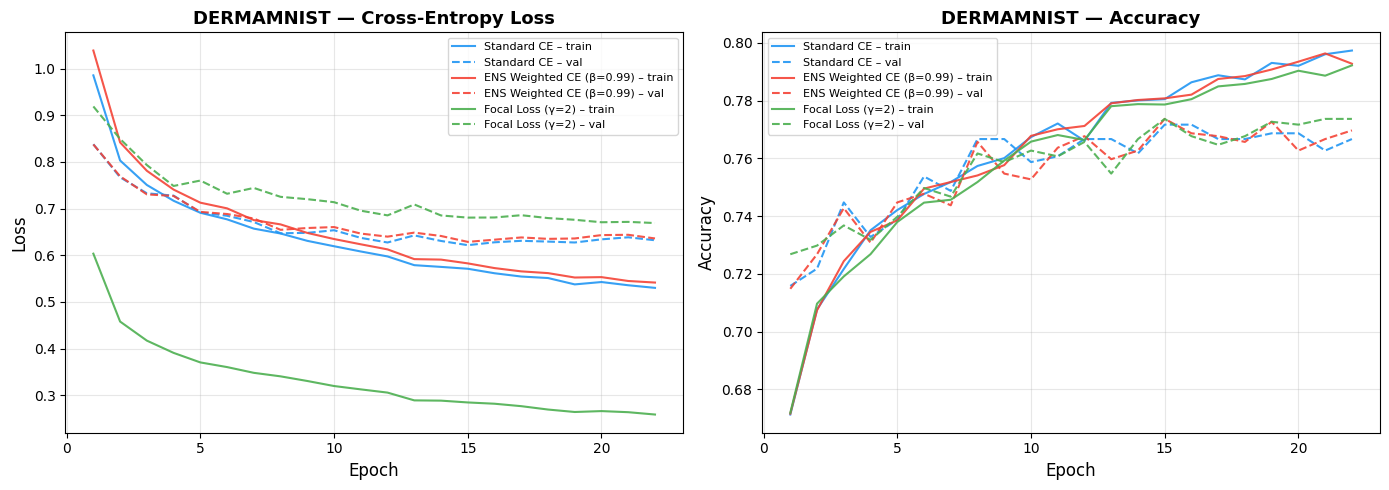

Saved: ../figures/W4_learning_curves_bloodmnist.png


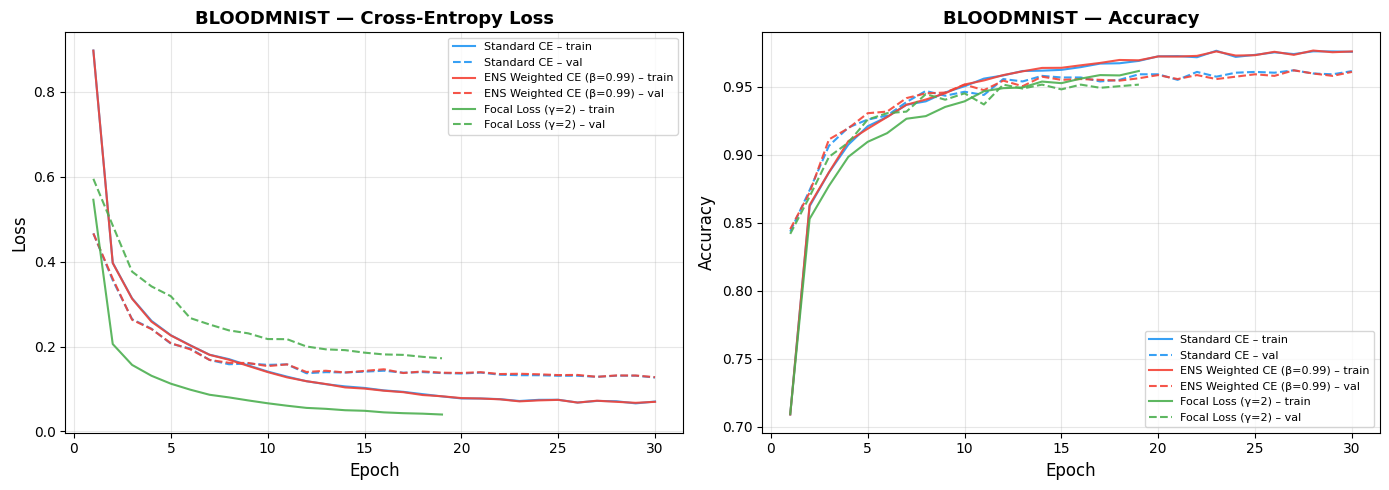

In [14]:
def plot_learning_curves(histories, dataset_name, experiments, save_path=None):
    """Plot train/val loss and accuracy for multiple loss functions on one dataset."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors    = ['#2196F3', '#F44336', '#4CAF50']

    for (key, lbl), color in zip(experiments, colors):
        if key not in histories: continue
        h   = histories[key]
        eps = range(1, len(h['train_loss']) + 1)
        axes[0].plot(eps, h['train_loss'], color=color, ls='-',  alpha=0.9, label=f'{lbl} – train')
        axes[0].plot(eps, h['val_loss'],   color=color, ls='--', alpha=0.9, label=f'{lbl} – val')
        axes[1].plot(eps, h['train_acc'],  color=color, ls='-',  alpha=0.9, label=f'{lbl} – train')
        axes[1].plot(eps, h['val_acc'],    color=color, ls='--', alpha=0.9, label=f'{lbl} – val')

    for ax, title, ylabel in zip(
        axes,
        [f'{dataset_name.upper()} — Cross-Entropy Loss',
         f'{dataset_name.upper()} — Accuracy'],
        ['Loss', 'Accuracy']
    ):
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


for ds in DATASETS:
    exps = [
        (f'{ds}__standard',    'Standard CE'),
        (f'{ds}__ens_weighted','ENS Weighted CE (β=0.99)'),
        (f'{ds}__focal',       'Focal Loss (γ=2)'),
    ]
    plot_learning_curves(all_histories, ds, exps,
                         save_path=f'../figures/W4_learning_curves_{ds}.png')

### 9.2 Confusion Matrices — DermaMNIST (All Loss Functions)

Saved: ../figures/W4_confusion_matrix_dermamnist_standard.png


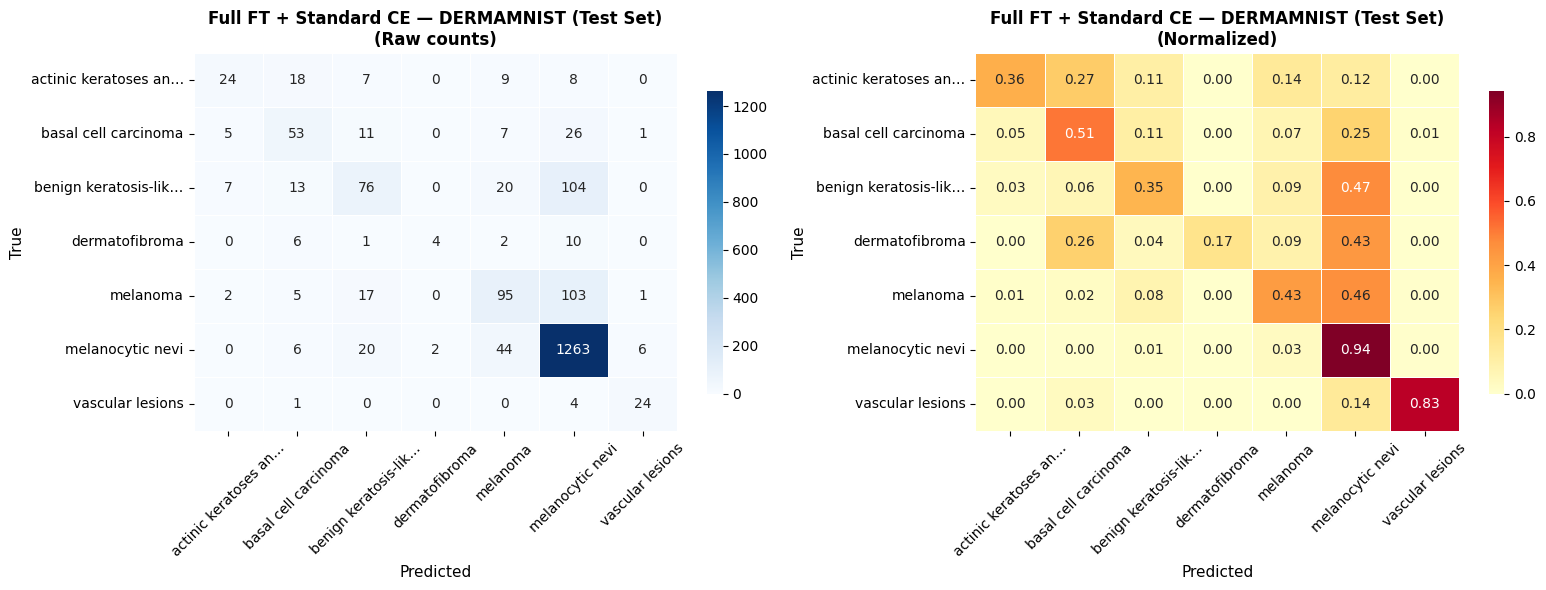

Saved: ../figures/W4_confusion_matrix_dermamnist_ens_weighted.png


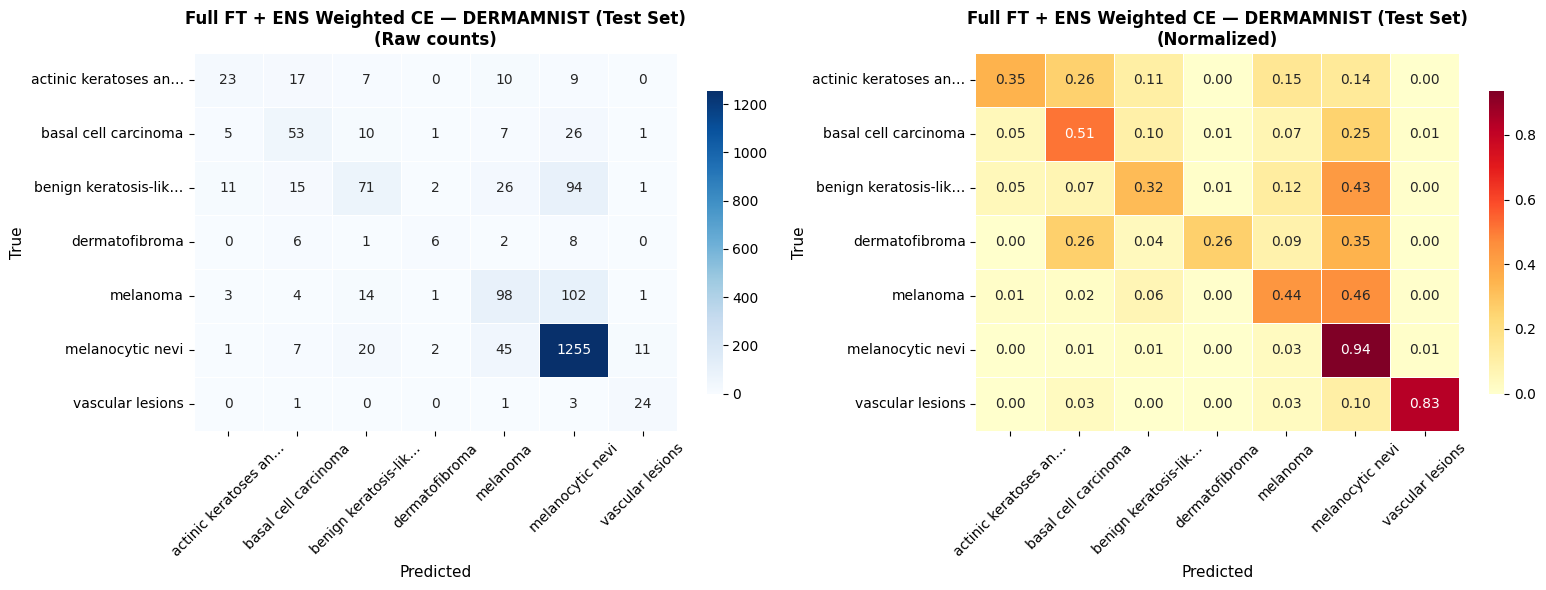

Saved: ../figures/W4_confusion_matrix_dermamnist_focal.png


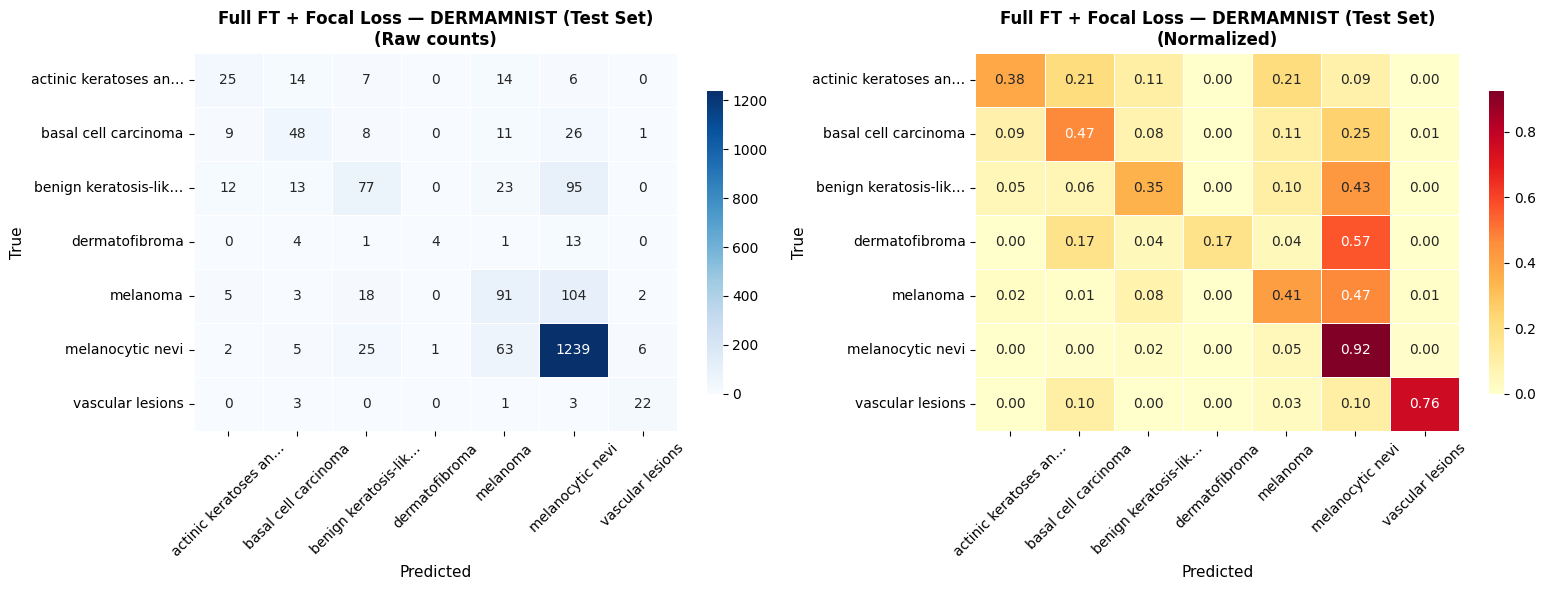

In [15]:
def plot_confusion_matrix(preds, labels, class_names, title, save_path=None):
    MAX_LEN     = 20
    class_names = [c[:MAX_LEN] + '…' if len(c) > MAX_LEN else c for c in class_names]
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, fmt, cmap, subtitle in zip(
        axes,
        [cm, cm_norm], ['d', '.2f'], ['Blues', 'YlOrRd'],
        ['Raw counts', 'Normalized']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True', fontsize=11)
        ax.set_title(f'{title}\n({subtitle})', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# Plot for all 3 loss functions on DermaMNIST
for loss_type, lbl in [('standard',    'Standard CE'),
                        ('ens_weighted','ENS Weighted CE'),
                        ('focal',       'Focal Loss')]:
    key = f'dermamnist__{loss_type}'
    if key not in all_results: continue
    r = all_results[key]
    plot_confusion_matrix(
        r['preds'], r['labels'], r['class_names'],
        title=f'Full FT + {lbl} — DERMAMNIST (Test Set)',
        save_path=f'../figures/W4_confusion_matrix_dermamnist_{loss_type}.png'
    )

### 9.3 Multi-Class ROC Curves

Saved: ../figures/W4_roc_dermamnist_best.png


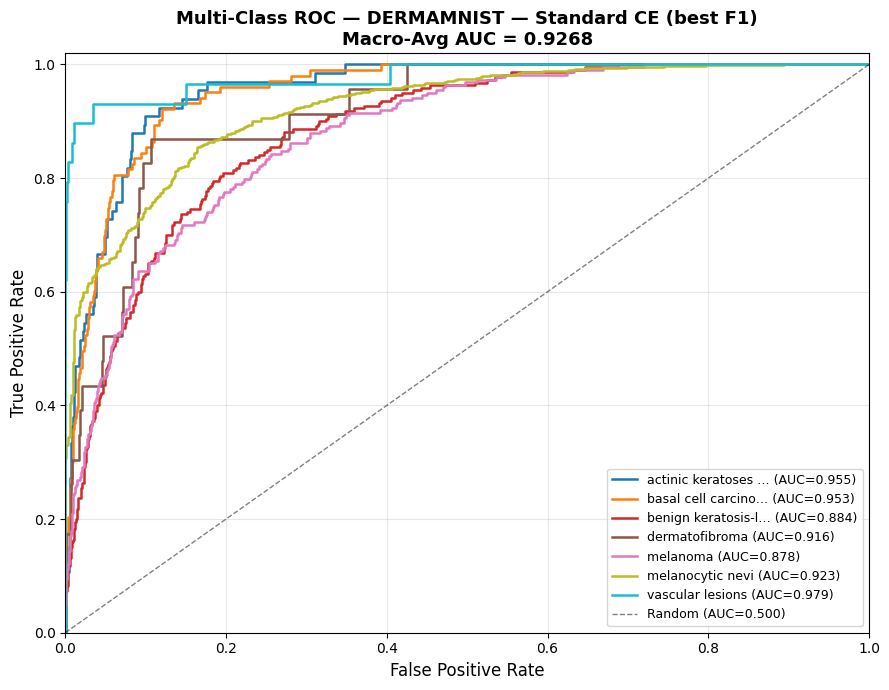

Saved: ../figures/W4_roc_bloodmnist_best.png


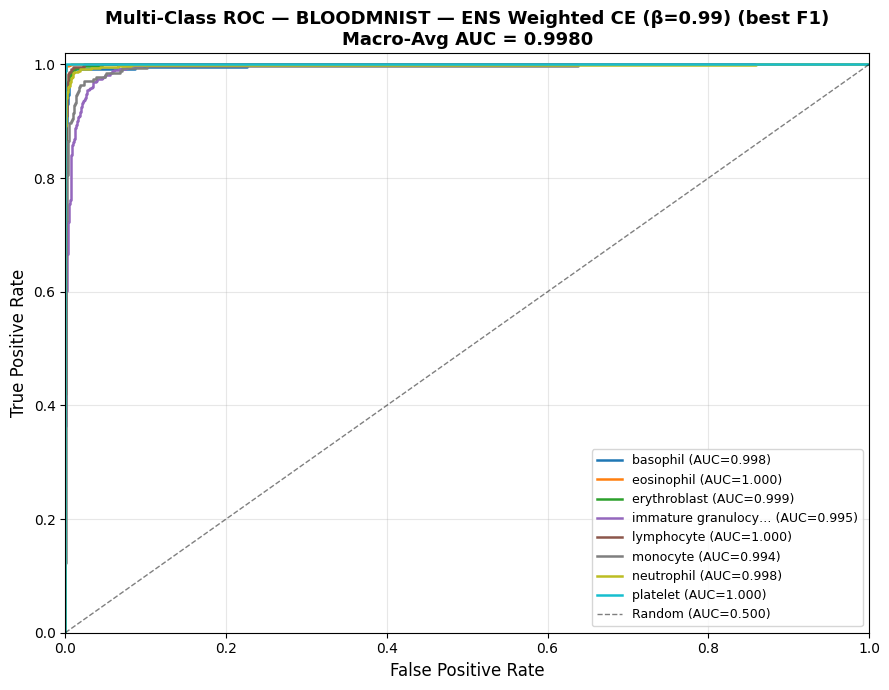

In [16]:
def plot_multiclass_roc(probs, labels, class_names, title, save_path=None):
    MAX_LEN    = 18
    n_classes  = len(class_names)
    labels_bin = label_binarize(labels, classes=list(range(n_classes)))

    fig, ax = plt.subplots(figsize=(9, 7))
    colors  = plt.cm.tab10(np.linspace(0, 1, n_classes))
    macro_auc = []

    for i, (cls_name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        macro_auc.append(roc_auc)
        short = cls_name[:MAX_LEN] + '…' if len(cls_name) > MAX_LEN else cls_name
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{short} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.500)')
    avg_auc = np.mean(macro_auc)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'{title}\nMacro-Avg AUC = {avg_auc:.4f}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# ROC for best F1 method per dataset
for ds in DATASETS:
    best_key = max([k for k in all_results if k.startswith(f'{ds}__')
                    and 'lp_' not in k],
                   key=lambda k: all_results[k]['f1_macro'])
    r = all_results[best_key]
    plot_multiclass_roc(
        r['probs'], r['labels'], r['class_names'],
        title=f"Multi-Class ROC — {ds.upper()} — {r['label']} (best F1)",
        save_path=f'../figures/W4_roc_{ds}_best.png'
    )

### 9.4 Bar Chart Comparison — All Loss Functions

Saved: ../figures/W4_comparison_accuracy.png


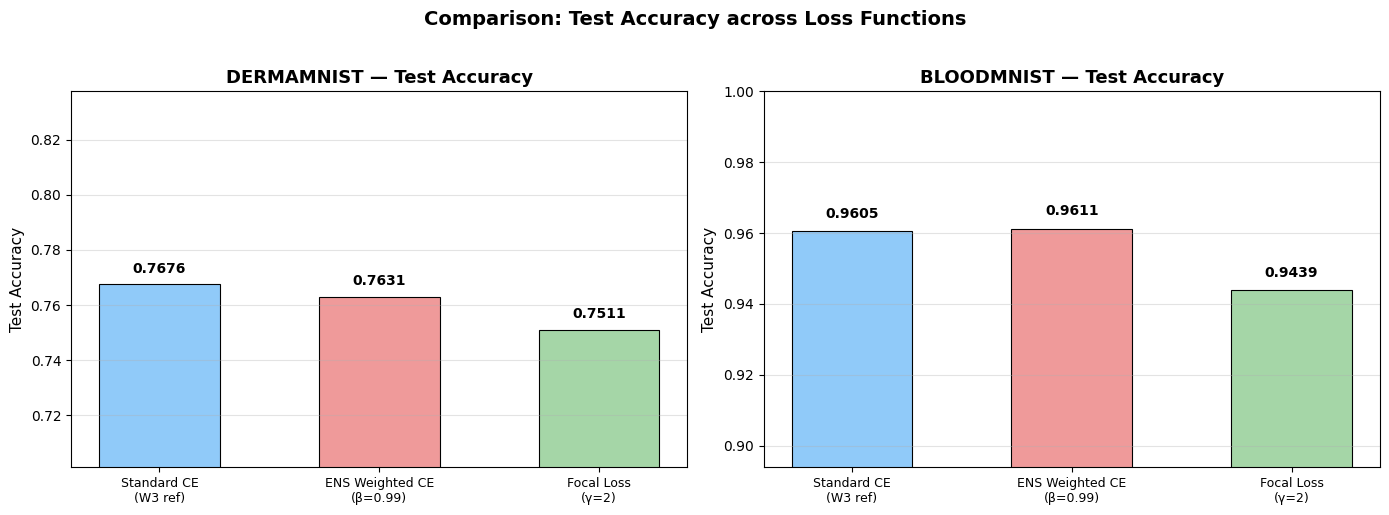

Saved: ../figures/W4_comparison_auc.png


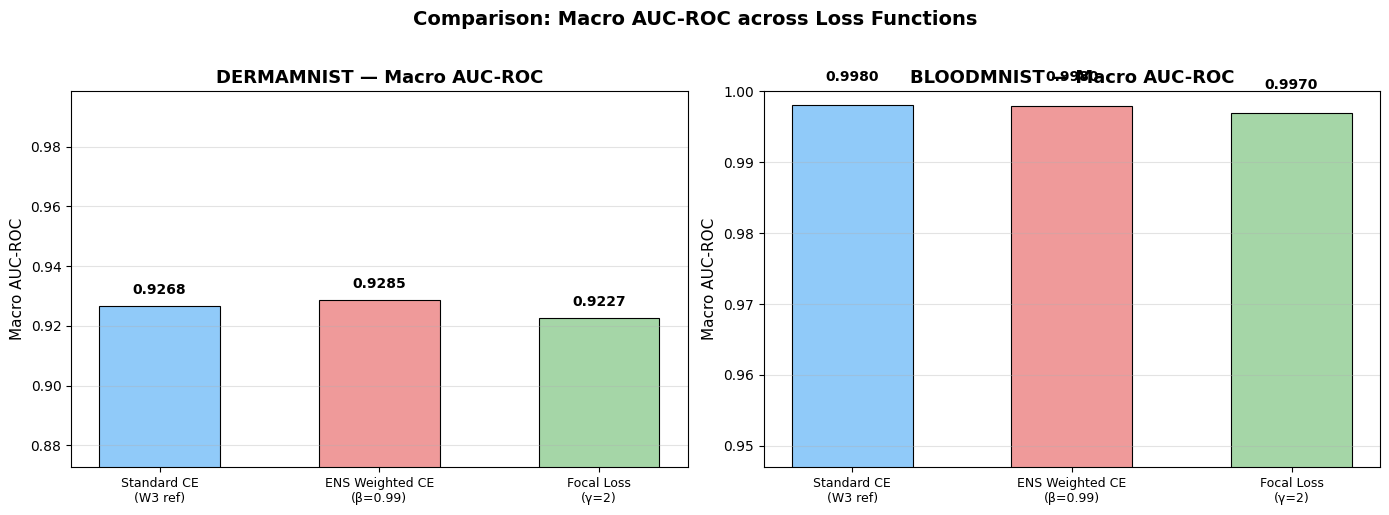

Saved: ../figures/W4_comparison_f1.png


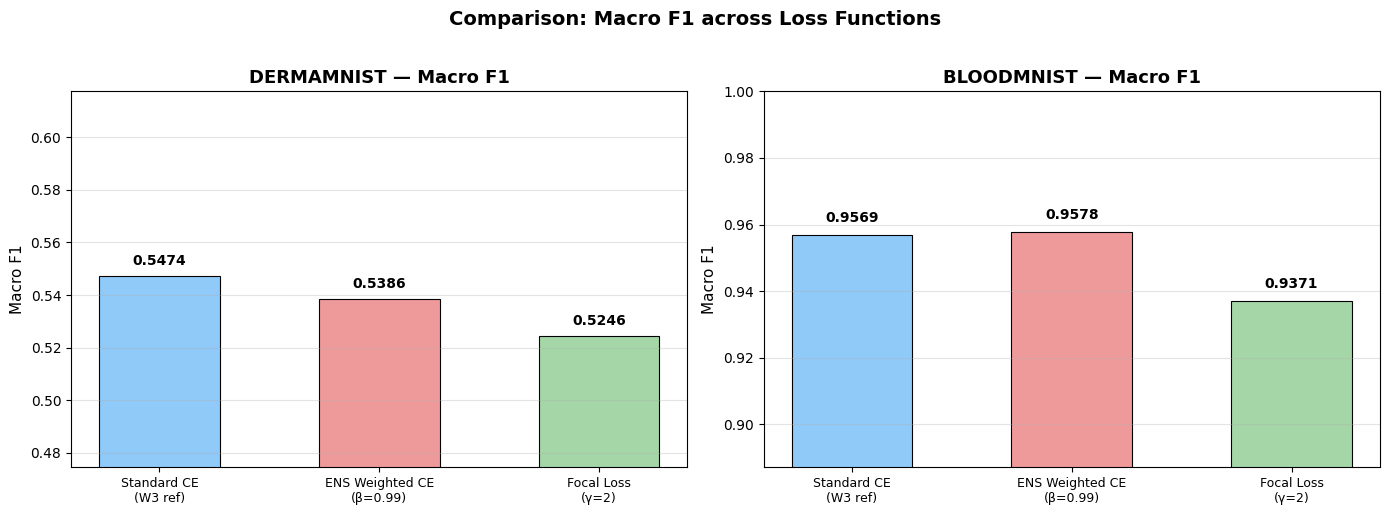

In [17]:
def plot_metric_comparison(all_results, metric='test_acc', metric_label='Test Accuracy',
                           save_path=None):
    loss_order  = ['standard', 'ens_weighted', 'focal']
    loss_labels = ['Standard CE\n(W3 ref)', 'ENS Weighted CE\n(β=0.99)', 'Focal Loss\n(γ=2)']
    colors      = ['#90CAF9', '#EF9A9A', '#A5D6A7']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, ds in zip(axes, DATASETS):
        vals, xlbls, bcolors = [], [], []
        for lt, lbl, c in zip(loss_order, loss_labels, colors):
            key = f'{ds}__{lt}'
            if key in all_results:
                vals.append(all_results[key][metric])
                xlbls.append(lbl)
                bcolors.append(c)

        bars = ax.bar(xlbls, vals, color=bcolors, edgecolor='black',
                      linewidth=0.8, width=0.55)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

        ax.set_title(f'{ds.upper()} — {metric_label}',
                     fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_ylim([max(0, min(vals) - 0.05), min(1, max(vals) + 0.07)])
        ax.grid(axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=9)

    plt.suptitle(f'Comparison: {metric_label} across Loss Functions',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_metric_comparison(all_results, metric='test_acc', metric_label='Test Accuracy',
                       save_path='../figures/W4_comparison_accuracy.png')
plot_metric_comparison(all_results, metric='auc',      metric_label='Macro AUC-ROC',
                       save_path='../figures/W4_comparison_auc.png')
plot_metric_comparison(all_results, metric='f1_macro', metric_label='Macro F1',
                       save_path='../figures/W4_comparison_f1.png')

### 9.5 Per-Class F1 Bar Chart — DermaMNIST 

This figure shows which classes benefit from each loss function.
The minority classes are highlighted in red.

Saved: ../figures/W4_perclass_f1_bars_dermamnist.png


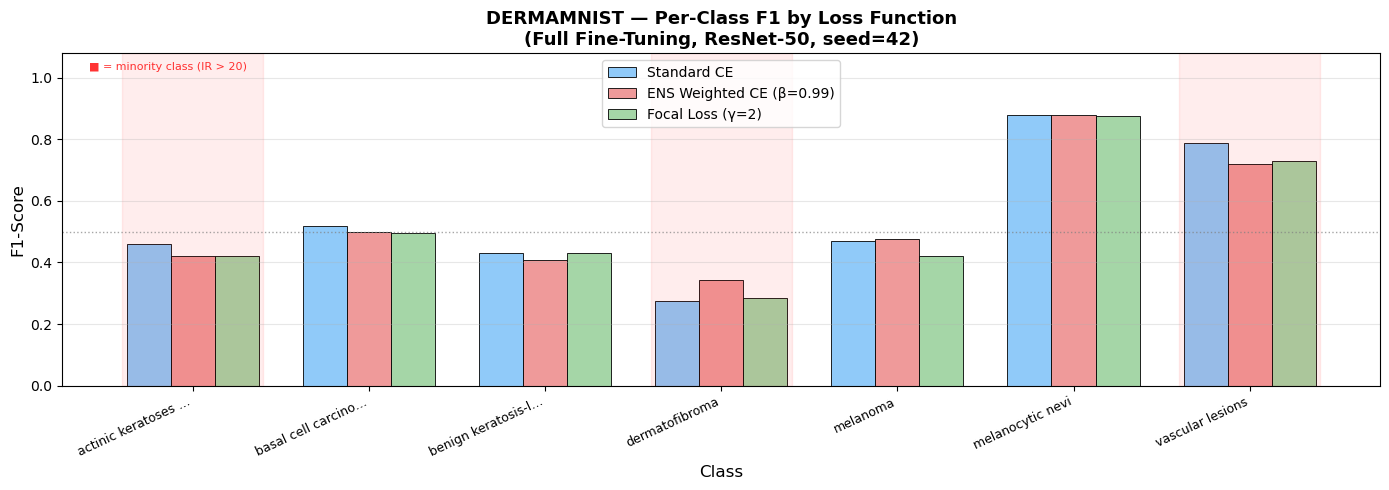

Saved: ../figures/W4_perclass_f1_bars_bloodmnist.png


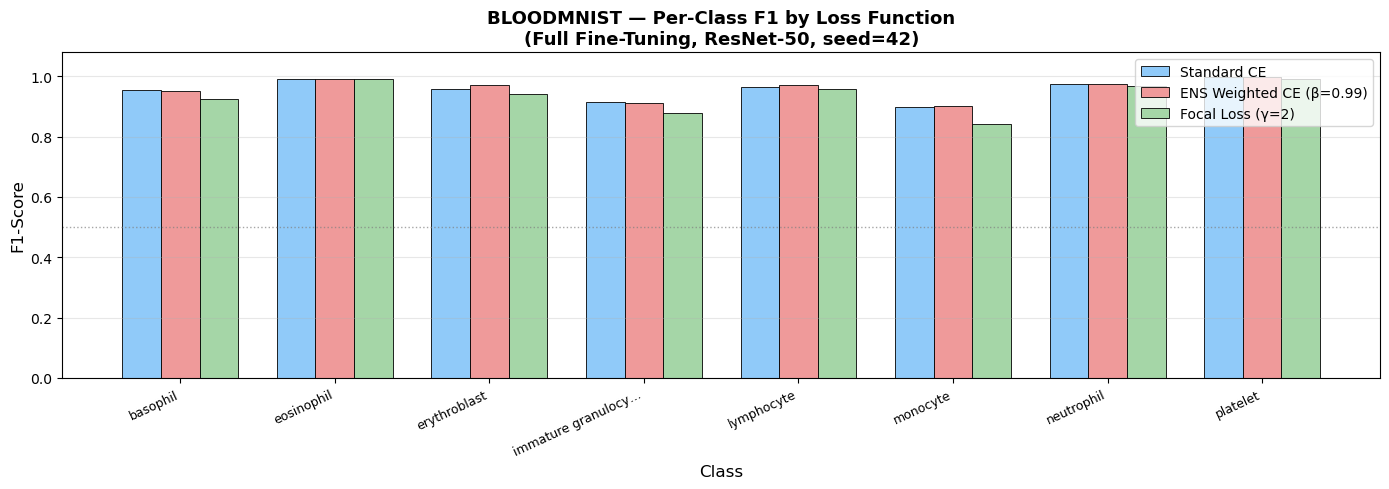

In [18]:
def plot_perclass_f1_bars(all_results, dataset_name, save_path=None):
    MAX_LEN     = 18
    loss_order  = ['standard', 'ens_weighted', 'focal']
    loss_labels = ['Standard CE', 'ENS Weighted CE (β=0.99)', 'Focal Loss (γ=2)']
    colors      = ['#90CAF9', '#EF9A9A', '#A5D6A7']

    key0        = f'{dataset_name}__standard'
    class_names = [c[:MAX_LEN] + '…' if len(c) > MAX_LEN else c
                   for c in all_results[key0]['class_names']]
    orig_names  = all_results[key0]['class_names']
    n_classes   = len(class_names)

    f1_data = {}
    for lt in loss_order:
        key = f'{dataset_name}__{lt}'
        if key not in all_results: continue
        r   = all_results[key]
        rep = classification_report(r['labels'], r['preds'],
                                    target_names=orig_names,
                                    output_dict=True, zero_division=0)
        f1_data[lt] = [rep[cn]['f1-score'] for cn in orig_names]

    x     = np.arange(n_classes)
    width = 0.25
    fig, ax = plt.subplots(figsize=(14, 5))

    for i, (lt, lbl, color) in enumerate(zip(loss_order, loss_labels, colors)):
        if lt not in f1_data: continue
        offset = (i - 1) * width
        ax.bar(x + offset, f1_data[lt], width, label=lbl,
               color=color, edgecolor='black', linewidth=0.6)

    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('F1-Score', fontsize=12)
    ax.set_title(f'{dataset_name.upper()} — Per-Class F1 by Loss Function\n'
                 f'(Full Fine-Tuning, ResNet-50, seed=42)',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=25, ha='right', fontsize=9)
    ax.set_ylim([0, 1.08])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)

    if dataset_name == 'dermamnist':
        for idx in [0, 3, 6]:   
            ax.axvspan(idx - 0.4, idx + 0.4, alpha=0.07, color='red')
        ax.text(0.02, 0.95, '■ = minority class (IR > 20)',
                transform=ax.transAxes, fontsize=8, color='red', alpha=0.8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


for ds in DATASETS:
    plot_perclass_f1_bars(all_results, ds,
                          save_path=f'../figures/W4_perclass_f1_bars_{ds}.png')

### 9.6 Per-Class F1 Heatmap

Saved: ../figures/W4_perclass_f1_heatmap_dermamnist.png


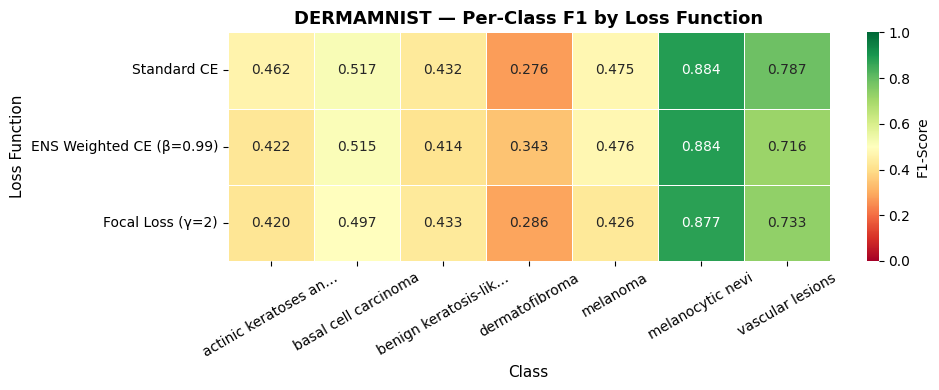

Saved: ../figures/W4_perclass_f1_heatmap_bloodmnist.png


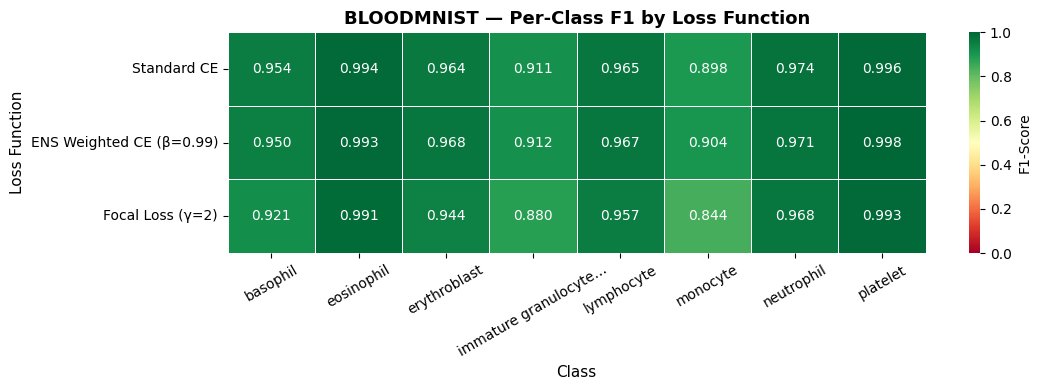

In [19]:
def plot_perclass_f1(all_results, dataset_name, loss_order, save_path=None):
    MAX_LEN     = 20
    loss_labels = [all_results[f'{dataset_name}__{lt}']['label']
                   for lt in loss_order if f'{dataset_name}__{lt}' in all_results]
    class_names = None
    f1_matrix   = []

    for lt in loss_order:
        key = f'{dataset_name}__{lt}'
        if key not in all_results: continue
        r   = all_results[key]
        if class_names is None:
            class_names = [c[:MAX_LEN] + '…' if len(c) > MAX_LEN else c
                           for c in r['class_names']]
        rep = classification_report(r['labels'], r['preds'],
                                    target_names=r['class_names'],
                                    output_dict=True, zero_division=0)
        f1_matrix.append([rep[cn]['f1-score'] for cn in r['class_names']])

    df_f1 = pd.DataFrame(f1_matrix, index=loss_labels, columns=class_names)
    fig, ax = plt.subplots(figsize=(max(10, len(class_names) * 1.4), 4))
    sns.heatmap(df_f1, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'F1-Score'})
    ax.set_title(f'{dataset_name.upper()} — Per-Class F1 by Loss Function',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Loss Function', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


loss_order = ['standard', 'ens_weighted', 'focal']
for ds in DATASETS:
    plot_perclass_f1(all_results, ds, loss_order,
                     save_path=f'../figures/W4_perclass_f1_heatmap_{ds}.png')

### 9.7 ECE Bar Chart — Global ECE vs Macro F1

Saved: ../figures/W4_ece_vs_f1.png


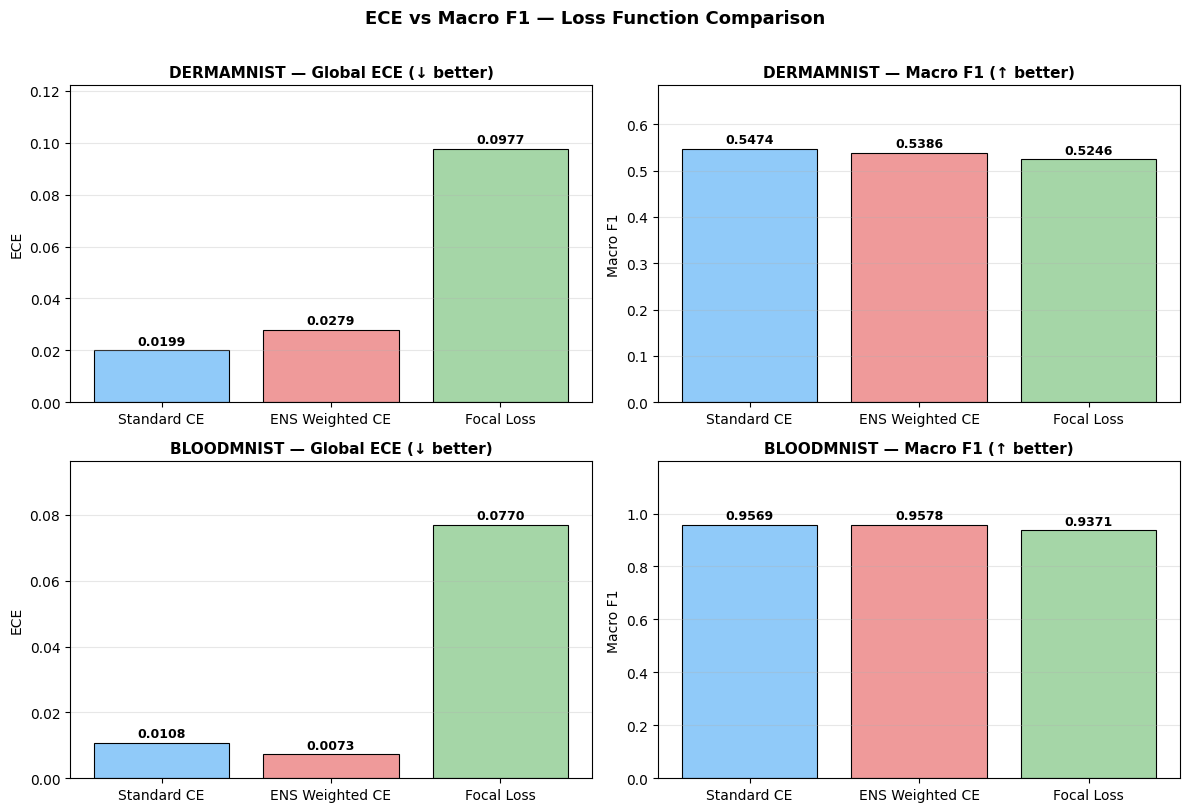

In [20]:
def plot_ece_comparison(all_results, ece_results, save_path=None):
    loss_order  = ['standard', 'ens_weighted', 'focal']
    loss_labels = ['Standard CE', 'ENS Weighted CE', 'Focal Loss']
    colors      = ['#90CAF9', '#EF9A9A', '#A5D6A7']

    fig, axes = plt.subplots(len(DATASETS), 2, figsize=(12, 8))

    for row, ds in enumerate(DATASETS):
        ece_vals = [ece_results[f'{ds}__{lt}']['global']
                    for lt in loss_order if f'{ds}__{lt}' in ece_results]
        f1_vals  = [all_results[f'{ds}__{lt}']['f1_macro']
                    for lt in loss_order if f'{ds}__{lt}' in all_results]
        lbls     = loss_labels[:len(ece_vals)]
        cols     = colors[:len(ece_vals)]

        for ax, vals, ylabel, title_suffix, ascending in zip(
            [axes[row][0], axes[row][1]],
            [ece_vals, f1_vals],
            ['ECE', 'Macro F1'],
            ['Global ECE (↓ better)', 'Macro F1 (↑ better)'],
            [True, False]
        ):
            bars = ax.bar(lbls, vals, color=cols, edgecolor='black', linewidth=0.8)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + max(vals) * 0.01,
                        f'{val:.4f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')
            ax.set_title(f'{ds.upper()} — {title_suffix}',
                         fontsize=11, fontweight='bold')
            ax.set_ylabel(ylabel, fontsize=10)
            ax.set_ylim([0, max(vals) * 1.25])
            ax.grid(axis='y', alpha=0.3)

    plt.suptitle('ECE vs Macro F1 — Loss Function Comparison',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_ece_comparison(all_results, ece_results,
                    save_path='../figures/W4_ece_vs_f1.png')

### 9.8 Per-Class ECE Heatmap 

Saved: ../figures/W4_perclass_ece_dermamnist.png


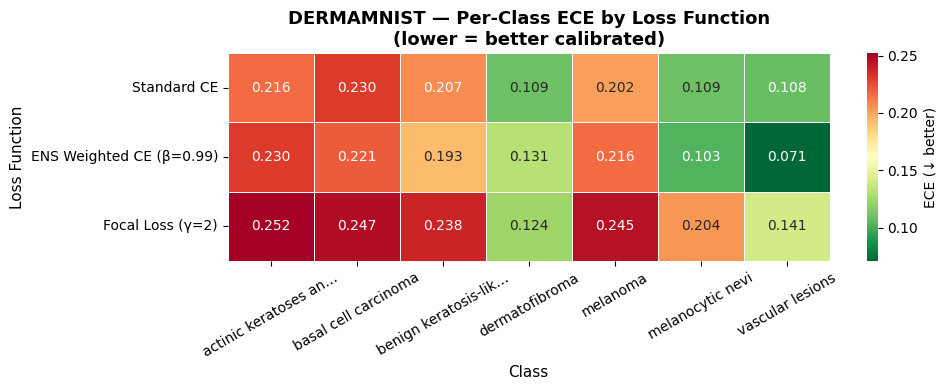

Saved: ../figures/W4_perclass_ece_bloodmnist.png


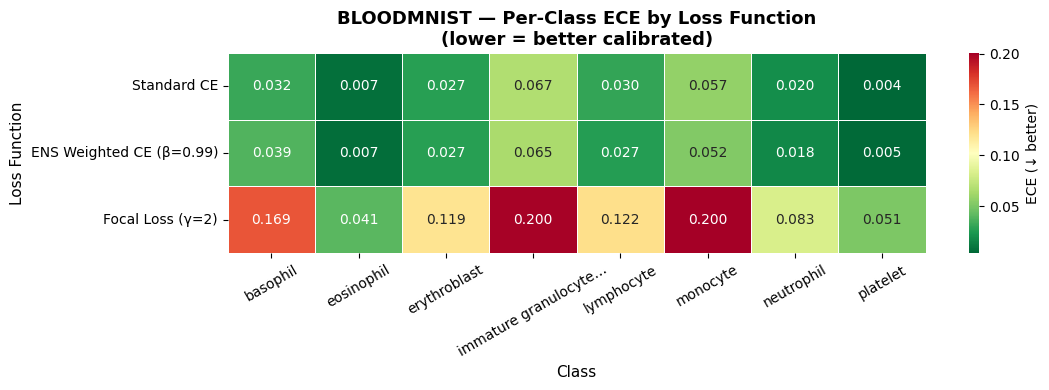

In [21]:
def plot_perclass_ece(all_results, ece_results, dataset_name, loss_order, save_path=None):
    MAX_LEN     = 20
    loss_labels = [all_results[f'{dataset_name}__{lt}']['label']
                   for lt in loss_order if f'{dataset_name}__{lt}' in all_results]
    key0        = f'{dataset_name}__standard'
    class_names = [c[:MAX_LEN] + '…' if len(c) > MAX_LEN else c
                   for c in all_results[key0]['class_names']]
    n_classes   = len(class_names)

    ece_matrix = []
    for lt in loss_order:
        key = f'{dataset_name}__{lt}'
        if key not in ece_results: continue
        row = [ece_results[key]['per_class'].get(c, float('nan'))
               for c in range(n_classes)]
        ece_matrix.append(row)

    df_ece = pd.DataFrame(ece_matrix, index=loss_labels[:len(ece_matrix)],
                          columns=class_names)
    fig, ax = plt.subplots(figsize=(max(10, n_classes * 1.4), 4))
    sns.heatmap(df_ece, annot=True, fmt='.3f', cmap='RdYlGn_r',
                ax=ax, linewidths=0.5, cbar_kws={'label': 'ECE (↓ better)'})
    ax.set_title(f'{dataset_name.upper()} — Per-Class ECE by Loss Function\n'
                 f'(lower = better calibrated)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Loss Function', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


loss_order = ['standard', 'ens_weighted', 'focal']
for ds in DATASETS:
    plot_perclass_ece(all_results, ece_results, ds, loss_order,
                      save_path=f'../figures/W4_perclass_ece_{ds}.png')

## 10. Full Protocol Summary

In [22]:
# ── Aggregate W3 + W4 for the complete protocol table ────────────────────────
protocol_rows = [
    # W3 results (from executed W3 notebooks)
    {'Dataset':'DermaMNIST','IR':58.7,'Week':'W3','Strategy':'Linear Probing',     'Acc':0.7312,'F1':0.4116,'AUC':0.8922},
    {'Dataset':'DermaMNIST','IR':58.7,'Week':'W3','Strategy':'Partial FT',         'Acc':0.7546,'F1':0.4930,'AUC':0.9287},
    {'Dataset':'DermaMNIST','IR':58.7,'Week':'W3','Strategy':'Full FT (Std CE)',   'Acc':0.7676,'F1':0.5474,'AUC':0.9268},
    {'Dataset':'DermaMNIST','IR':58.7,'Week':'W3','Strategy':'SimCLR → Full FT',  'Acc':0.7741,'F1':0.5698,'AUC':0.9397},
    {'Dataset':'DermaMNIST','IR':58.7,'Week':'W3','Strategy':'DTL (Blood→Derma)', 'Acc':0.7945,'F1':0.5728,'AUC':None},
    {'Dataset':'BloodMNIST','IR': 2.7,'Week':'W3','Strategy':'Linear Probing',    'Acc':0.7822,'F1':0.7417,'AUC':0.9683},
    {'Dataset':'BloodMNIST','IR': 2.7,'Week':'W3','Strategy':'Partial FT',        'Acc':0.9421,'F1':0.9357,'AUC':0.9963},
    {'Dataset':'BloodMNIST','IR': 2.7,'Week':'W3','Strategy':'Full FT (Std CE)',  'Acc':0.9605,'F1':0.9569,'AUC':0.9980},
    {'Dataset':'BloodMNIST','IR': 2.7,'Week':'W3','Strategy':'SimCLR → Full FT', 'Acc':0.9740,'F1':0.9723,'AUC':0.9984},
    {'Dataset':'BloodMNIST','IR': 2.7,'Week':'W3','Strategy':'DTL (Derma→Blood)','Acc':0.9737,'F1':0.9725,'AUC':None},
]

# Add W4 results
for key, r in all_results.items():
    ds_label = 'DermaMNIST' if 'derma' in r['dataset'] else 'BloodMNIST'
    protocol_rows.append({
        'Dataset'  : ds_label,
        'IR'       : IMBALANCE_RATIOS[r['dataset']],
        'Week'     : 'W4',
        'Strategy' : f"Full FT + {r['label']}",
        'Acc'      : round(r['test_acc'], 4),
        'F1'       : round(r['f1_macro'], 4),
        'AUC'      : round(r['auc'],      4),
    })

df_protocol = pd.DataFrame(protocol_rows)

print("\n" + "="*85)
print("COMPLETE PROTOCOL — All Methods, All Weeks (ranked by F1)")
print("="*85)
for ds_label in ['DermaMNIST', 'BloodMNIST']:
    sub = df_protocol[df_protocol['Dataset'] == ds_label].sort_values('F1', ascending=False)
    print(f"\n  {ds_label}")
    print(sub[['Week','Strategy','Acc','F1','AUC']].to_string(index=False))

print("\n\nRecommended Protocol:")
print("  IR < 5  (balanced)  → Partial Fine-Tuning")
print("  5 ≤ IR < 20         → Full Fine-Tuning + Standard CE")
print("  IR ≥ 20 (severe)    → Full FT + SimCLR or DTL for best F1")
print("  IR ≥ 20 + calibration → Full FT + class-balanced loss improves minority ECE")

df_protocol.to_csv('../experiments/W4_protocol_full.csv', index=False)
print("\nSaved: ../experiments/W4_protocol_full.csv")


COMPLETE PROTOCOL — All Methods, All Weeks (ranked by F1)

  DermaMNIST
Week                           Strategy    Acc     F1    AUC
  W3                  DTL (Blood→Derma) 0.7945 0.5728    NaN
  W3                   SimCLR → Full FT 0.7741 0.5698 0.9397
  W3                   Full FT (Std CE) 0.7676 0.5474 0.9268
  W4              Full FT + Standard CE 0.7676 0.5474 0.9268
  W4 Full FT + ENS Weighted CE (β=0.99) 0.7631 0.5386 0.9285
  W4         Full FT + Focal Loss (γ=2) 0.7511 0.5246 0.9227
  W3                         Partial FT 0.7546 0.4930 0.9287
  W3                     Linear Probing 0.7312 0.4116 0.8922
  W4         Full FT + LP + Weighted CE 0.7297 0.4107 0.8938

  BloodMNIST
Week                           Strategy    Acc     F1    AUC
  W3                  DTL (Derma→Blood) 0.9737 0.9725    NaN
  W3                   SimCLR → Full FT 0.9740 0.9723 0.9984
  W4 Full FT + ENS Weighted CE (β=0.99) 0.9611 0.9578 0.9980
  W3                   Full FT (Std CE) 0.9605 0.9569 0.998

## 11. Detailed Classification Reports

In [23]:
for key, r in all_results.items():
    print(f"\n{'='*65}")
    print(f" Classification Report: {key}")
    print(f"{'='*65}")
    print(classification_report(
        r['labels'], r['preds'],
        target_names=r['class_names'], zero_division=0
    ))
    print(f" Test Accuracy : {r['test_acc']:.4f}")
    print(f" Macro AUC-ROC : {r['auc']:.4f}")
    print(f" Macro F1      : {r['f1_macro']:.4f}")
    print(f" Global ECE    : {ece_results[key]['global']:.4f}")


 Classification Report: dermamnist__standard
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.63      0.36      0.46        66
                           basal cell carcinoma       0.52      0.51      0.52       103
                  benign keratosis-like lesions       0.58      0.35      0.43       220
                                 dermatofibroma       0.67      0.17      0.28        23
                                       melanoma       0.54      0.43      0.47       223
                               melanocytic nevi       0.83      0.94      0.88      1341
                               vascular lesions       0.75      0.83      0.79        29

                                       accuracy                           0.77      2005
                                      macro avg       0.64      0.51      0.55      2005
                                   weighted avg       0.75    

## 12. Save All Experiment Logs

In [24]:
# Save per-epoch histories to CSV
for key, h in all_histories.items():
    df_hist = pd.DataFrame({
        'epoch':      list(range(1, len(h['train_loss']) + 1)),
        'train_loss': h['train_loss'],
        'train_acc':  h['train_acc'],
        'val_loss':   h['val_loss'],
        'val_acc':    h['val_acc'],
        'lr':         h['lr'],
    })
    path = f'../experiments/history_{key}.csv'
    df_hist.to_csv(path, index=False)
    print(f"Saved: {path}")

print("\nAll figures  → ../figures/W4_*.png")
print("All logs     → ../experiments/W4_*.csv")
print("All models   → ../models/*_best.pth")

Saved: ../experiments/history_dermamnist__standard.csv
Saved: ../experiments/history_dermamnist__ens_weighted.csv
Saved: ../experiments/history_dermamnist__focal.csv
Saved: ../experiments/history_bloodmnist__standard.csv
Saved: ../experiments/history_bloodmnist__ens_weighted.csv
Saved: ../experiments/history_bloodmnist__focal.csv
Saved: ../experiments/history_dermamnist__lp_weighted.csv

All figures  → ../figures/W4_*.png
All logs     → ../experiments/W4_*.csv
All models   → ../models/*_best.pth
